In [2]:
import h3
import pandas as pd
# import pyarrow
import geopandas
import contextily as cx
import h3pandas
import plotly.express as px

import contextily as cx
import matplotlib.pyplot as plt
import folium


res = 7

In [3]:
def plot_df(df, column=None, ax=None):
    "Plot based on the `geometry` column of a GeoPandas dataframe"
    df = df.copy()
    df = df.to_crs(epsg=3857)  # web mercator

    if ax is None:
        _, ax = plt.subplots(figsize=(8,8))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    df.plot(
        ax=ax,
        alpha=0.5, edgecolor='k',
        column=column, categorical=True,
        legend=True, legend_kwds={'loc': 'upper left'},
    )
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)


def plot_shape(shape, ax=None):
    df = geopandas.GeoDataFrame({'geometry': [shape]}, crs='EPSG:4326')
    plot_df(df, ax=ax)


def plot_cells(cells, ax=None):
    shape = h3.cells_to_h3shape(cells)
    plot_shape(shape, ax=ax)


def plot_shape_and_cells(shape, res=9):
    fig, axs = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)
    plot_shape(shape, ax=axs[0])
    plot_cells(h3.h3shape_to_cells(shape, res), ax=axs[1])
    fig.tight_layout()

In [4]:
alerts_path = "../Datasets/WSSC_Alerts/wssc_alerts_geocoded.shp"
alerts_df = geopandas.read_file(alerts_path)
alerts_df.head()

,Unnamed:_0,title,date,pipe_diame,address,corrected_,full_text,geocode_qu,latitude,longitude,geocode_st,geometry
0,0,Emergency Water Main Repair - Takoma Park,"December 30, 2022",8,"602 Ethan Allen Avenue, Takoma Park","602 Ethan Allen Avenue, Takoma Park","Laurel, MD â December 30, 2022: WSSC Water i...","602 Ethan Allen Avenue, Takoma Park, Maryland,...",38.976122,-76.996519,ok,POINT (-76.99652 38.97612)
1,1,Emergency Water Main Repair - Capitol Heights,"December 29, 2022",12,"6180 Old Central Avenue, Rollins Avenue, Capit...","6180 Old Central Avenue, Rollins Avenue, Capit...","Laurel, MD â December 29, 2022: WSSC Water i...","6180 Old Central Avenue, Rollins Avenue, Capit...",38.886057,-76.903669,ok,POINT (-76.90367 38.88606)
2,2,Emergency Water Main Repair - Oxon Hill,"December 29, 2022",8,"801 Owens Road, Oxon Hill","801 Owens Road, Oxon Hill","Laurel, MD â December 29, 2022: WSSC Water i...","801 Owens Road, Oxon Hill, Maryland, USA",38.824928,-76.995675,ok,POINT (-76.99568 38.82493)
3,3,Emergency Water Main Repair - Silver Spring,"December 28, 2022",8,"12001 Old Columbia Pike, Silver Spring","12001 Old Columbia Pike, Silver Spring","Laurel, MD â December 28, 2022: WSSC Water i...","12001 Old Columbia Pike, Silver Spring, Maryla...",39.052508,-76.976358,ok,POINT (-76.97636 39.05251)
4,4,Emergency Water Main Repair - Greenbelt,"December 28, 2022",10,"9115 Springhill Ln, Greenbelt","9115 Springhill Ln, Greenbelt","Laurel, MD â December 28, 2022: WSSC Water i...","9115 Springhill Ln, Greenbelt, Maryland, USA",39.002690,-76.903941,ok,POINT (-76.90394 39.00269)


In [5]:
traffic_path = "../Datasets/MDOT_SHA_Annual_Average_Daily_Traffic_locations/MDOT_SHA_Annual_Average_Daily_Traffic_(AADT)_Locations.shp"
traffic_df = geopandas.read_file(traffic_path)
traffic_df = traffic_df[(traffic_df["COUNTY_DES"] == "MONTGOMERY") | (traffic_df["COUNTY_DES"] == "PRINCE GEORGE'S")]
traffic_df = traffic_df.to_crs("EPSG:4326")
traffic_df.head()


/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


,LOCATION_I,COUNTY_ID,COUNTY_DES,MUN_SORT,MUNICIPALI,ROADNAME,ID_PREFIX,ID_RTE_NO,MP_SUFFIX,ID_MP,...,AADT_2020,AAWDT_2020,AADT_2021,AAWDT_2021,AADT_2022,AAWDT_2022,GlobalID,AADT_2023,AAWDT_2023,geometry
2376,B2847,15.0,MONTGOMERY,0.0,NONE,EISENHOWER MEMORIAL HWY,IS,270.0,NaN,6.96,...,189022.0,198472.0,179810.0,185200.0,181431.0,186871.0,58a6e6d3-c998-4c66-91a6-4cf4306a1de1,186332.0,191922.0,POINT Z (-77.17565 39.09275 0)
2377,S2012150895,15.0,MONTGOMERY,0.0,NONE,PARK VISTA DR,CO,6171.0,NaN,0.12,...,1862.0,2012.0,2133.0,2243.0,2154.0,2284.0,e0af517d-fced-4e6d-8299-4cbcfbfe1605,2195.0,2375.0,POINT Z (-77.04283 39.10121 0)
2378,S2012150815,15.0,MONTGOMERY,0.0,NONE,E DEER PARK DR,CO,3138.0,NaN,0.64,...,4592.0,4962.0,5253.0,5523.0,5294.0,5614.0,f7ba538a-fff0-4286-bd42-c281d982775b,5375.0,5815.0,POINT Z (-77.17933 39.1375 0)
2384,S2012150832,15.0,MONTGOMERY,0.0,NONE,WESTLAKE TERR,CO,3438.0,NaN,0.39,...,11802.0,12752.0,13503.0,14183.0,13584.0,14404.0,1039fef6-61c7-485b-b675-a27c04fa8eda,13795.0,14905.0,POINT Z (-77.14654 39.02694 0)
2386,S2012150751,15.0,MONTGOMERY,0.0,NONE,SANGAMORE RD,CO,507.0,NaN,0.11,...,7102.0,7672.0,8133.0,8543.0,8184.0,8684.0,6e362e3d-6b1c-4c3c-951d-18b24ef01cc8,8315.0,8985.0,POINT Z (-77.12125 38.96311 0)


In [6]:
traffic_h3 = traffic_df.h3.geo_to_h3_aggregate(res,operation={'AAWDT_2023': 'mean'}).reset_index()
traffic_h3.head()

,h3_07,AAWDT_2023,geometry
0,872aa8080ffffff,8000.000000,"POLYGON ((-76.75096 38.95962, -76.76477 38.952..."
1,872aa8081ffffff,5324.500000,"POLYGON ((-76.73482 38.94233, -76.74863 38.935..."
2,872aa8082ffffff,8452.000000,"POLYGON ((-76.77975 38.95813, -76.79355 38.951..."
3,872aa8084ffffff,4301.000000,"POLYGON ((-76.7383 38.97841, -76.75212 38.9716..."
4,872aa8085ffffff,21208.823529,"POLYGON ((-76.72217 38.96111, -76.73598 38.954..."


In [7]:
traffic_h3.count()

h3_07         321
AAWDT_2023    321
geometry      321
dtype: int64

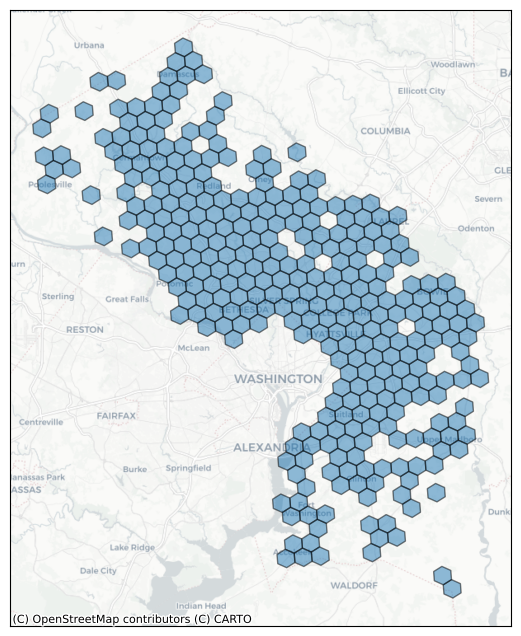

In [8]:
plot_df(traffic_h3)

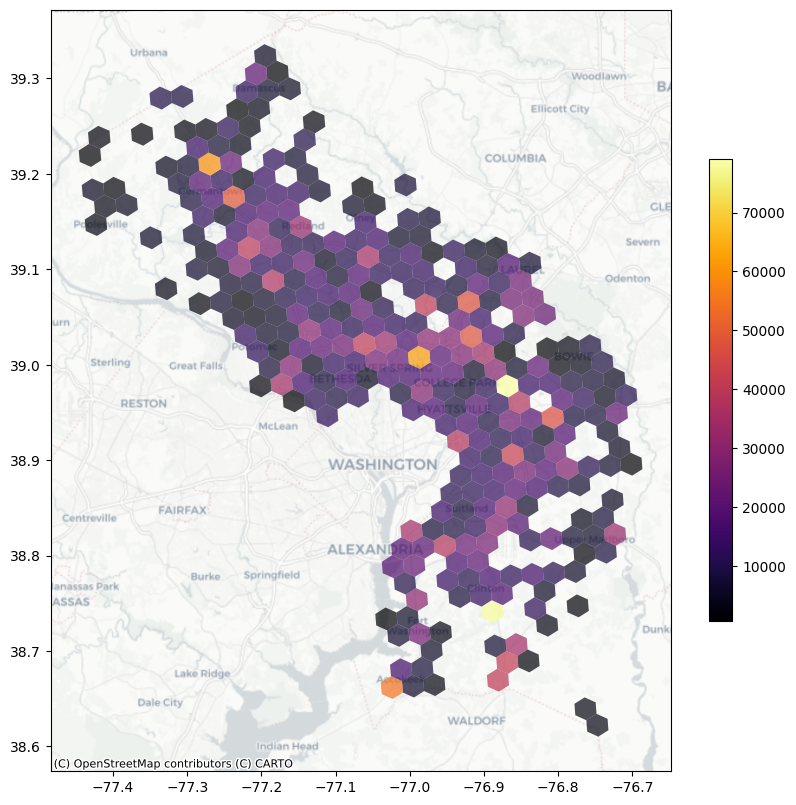

In [9]:
ax = traffic_h3.plot(
    column='AAWDT_2023',
    figsize=(10, 10),
    cmap='inferno',
    alpha=0.7,
    legend=True,
    legend_kwds={'shrink': 0.6}
)
cx.add_basemap(ax, crs=traffic_h3.crs, source=cx.providers.CartoDB.Positron, zoom=10)

In [10]:
traffic_line_path = "../Datasets/MDOT_SHA_Annual_Average_Daily_Traffic_segments/MDOT_SHA_Annual_Average_Daily_Traffic_(AADT)_Segments.shp"
traffic_line_df = geopandas.read_file(traffic_line_path)
traffic_line_df = traffic_line_df[(traffic_line_df["COUNTY_DES"] == "MONTGOMERY") | (traffic_line_df["COUNTY_DES"] == "PRINCE GEORGE'S")]
traffic_line_df = traffic_line_df.to_crs("EPSG:4326")
traffic_line_df.head()

/home/emmaf/miniconda3/envs/sewer_repair_data/lib/python3.14/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


,LOCATION_I,COUNTY_ID,COUNTY_DES,MUN_SORT,MUNICIPALI,ROADNAME,ID_PREFIX,ID_RTE_NO,MP_SUFFIX,ID_MP,...,AADT_2020,AAWDT_2020,AADT_2021,AAWDT_2021,AADT_2022,AAWDT_2022,GlobalID,AADT_2023,AAWDT_2023,geometry
4178,S2012150903,15.0,MONTGOMERY,0.0,NONE,DAWSON FARM RD,CO,7031.0,NaN,0.82,...,3472.0,3752.0,3973.0,4173.0,4004.0,4244.0,3f8be9bd-e5b1-4f41-935c-995c4124c375,4065.0,4395.0,"LINESTRING Z (-77.28372 39.1734 0, -77.28354 3..."
4428,B150034,15.0,MONTGOMERY,0.0,NONE,HATHAWAY DR,CO,1418.0,NaN,-1.00,...,2471.0,2671.0,2832.0,2972.0,2853.0,3023.0,df7b4300-c9f9-4dcc-8a90-1c8113412ead,2904.0,3144.0,"LINESTRING Z (-77.06405 39.06308 0, -77.06416 ..."
4432,B2527,15.0,MONTGOMERY,0.0,NONE,WOODBINE RD,CO,46.0,NaN,-1.00,...,4661.0,4941.0,5542.0,5822.0,5403.0,5573.0,38d97f80-3164-4ce9-a5fd-2fc29916308f,5594.0,5934.0,"LINESTRING Z (-77.15233 39.26928 0, -77.15205 ..."
4435,B150123,15.0,MONTGOMERY,0.0,NONE,W DIAMOND AVE,CO,7885.0,NaN,0.10,...,9311.0,10061.0,10652.0,11402.0,10723.0,11583.0,f95ef559-1093-48f3-91a4-297879f523c5,10884.0,11544.0,"LINESTRING Z (-77.20496 39.14008 0, -77.20488 ..."
4439,S2012150696,15.0,MONTGOMERY,0.0,NONE,SEVEN LOCKS RD,CO,148.0,NaN,4.07,...,11622.0,12552.0,13303.0,14233.0,13384.0,14464.0,c44e8401-0084-4c76-ad29-754b9347b657,13595.0,14415.0,"LINESTRING Z (-77.16233 39.02327 0, -77.16234 ..."


In [11]:
county_boundaries = geopandas.read_file("../Datasets/tl_2025_us_county/tl_2025_us_county.shp")
county_boundaries = county_boundaries[county_boundaries["STATEFP"].eq("24") & county_boundaries["COUNTYFP"].isin(["031","033"])]
county_boundaries = county_boundaries.to_crs("EPSG:4326")
county_boundaries.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
1531,24,033,01714670,24033,0500000US24033,Prince George's,Prince George's County,06,H1,G4020,548,47900,47764,A,1249930975,42051952,+38.8292778,-076.8481880,"POLYGON ((-76.93192 38.91052, -76.932 38.91058..."
1662,24,031,01712500,24031,0500000US24031,Montgomery,Montgomery County,06,H1,G4020,548,47900,23224,A,1277231475,35632833,+39.1373815,-077.2030633,"POLYGON ((-77.14467 39.29471, -77.14457 39.294..."


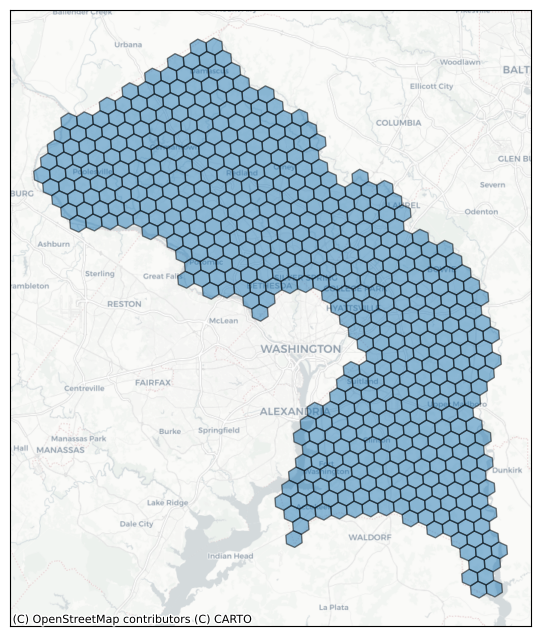

In [12]:
pg_mc_h3 = county_boundaries.h3.polyfill_resample(resolution=res)
plot_df(pg_mc_h3)
# ax = traffic_line_df.plot(
#     figsize=(10, 10),
#     # cmap='inferno',
#     alpha=0.7,
#     legend=True,
#     legend_kwds={'shrink': 0.6}
# )
# # pg_mc_h3.head()

In [13]:
traffic_line_df.geometry

4178    LINESTRING Z (-77.28372 39.1734 0, -77.28354 3...
4428    LINESTRING Z (-77.06405 39.06308 0, -77.06416 ...
4432    LINESTRING Z (-77.15233 39.26928 0, -77.15205 ...
4435    LINESTRING Z (-77.20496 39.14008 0, -77.20488 ...
4439    LINESTRING Z (-77.16233 39.02327 0, -77.16234 ...
                              ...                        
9009    LINESTRING Z (-76.85504 39.10637 0, -76.85645 ...
9010    LINESTRING Z (-76.83134 38.89838 0, -76.83124 ...
9014    LINESTRING Z (-76.83657 38.89932 0, -76.83645 ...
9015    LINESTRING Z (-76.90256 38.99321 0, -76.90192 ...
9020    LINESTRING Z (-76.86126 38.83024 0, -76.86142 ...
Name: geometry, Length: 2395, dtype: geometry

In [14]:
df = px.data.gapminder().query("year == 2007")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


In [15]:
m = folium.Map(tiles="CartoDB Positron")
folium.GeoJson(traffic_h3).add_to(m)

m.fit_bounds(m.get_bounds())

m

In [17]:
m = folium.Map(tiles="CartoDB Positron")
# folium.GeoJson(traffic_h3).add_to(m)



folium.Choropleth(
    geo_data=traffic_h3,
    data=traffic_h3,
    columns=[f"h3_0{res}", "AAWDT_2023"],
    fill_color="inferno",
    line_color=None,
    highlight=True,
    key_on=f"feature.properties.h3_0{res}",
).add_to(m)


m.fit_bounds(m.get_bounds())

m

# If you're using vscode and get a message about need to trust this notebook, or if the basemap doesn't load correctly, try adding an empty markdown cell after this (or delete and recreate, if one already exists)